In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available. Enable T4 GPU in Colab.")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers torchvision pillow kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 106.0 MB/s eta 0:00:00


In [4]:
!pip install -q huggingface_hub

In [5]:
from huggingface_hub import login

login()

In [13]:
import torch
from transformers import AutoModelForImageSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForImageSegmentation.from_pretrained(
    "briaai/RMBG-2.0",
    trust_remote_code=True
).eval().to(device)

print("Model loaded successfully!")
print("Running on:", device)

Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

Model loaded successfully!
Running on: cuda


In [14]:
from google.colab import files

uploaded = files.upload()

input_image_path = list(uploaded.keys())[0]

print("Uploaded:", input_image_path)

Saving cshong-o4ZTj9m91WU-unsplash.jpg to cshong-o4ZTj9m91WU-unsplash.jpg
Uploaded: cshong-o4ZTj9m91WU-unsplash.jpg


In [15]:
from PIL import Image
from torchvision import transforms

# Image size expected by the model
image_size = (1024, 1024)

transform_image = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Open image
image = Image.open(input_image_path).convert("RGB")

# Transform
input_images = transform_image(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    preds = model(input_images)[-1].sigmoid().cpu()

pred = preds[0].squeeze()

# Convert prediction to PIL mask
pred_pil = transforms.ToPILImage()(pred)

# Resize mask to original image dimensions
mask = pred_pil.resize(image.size)

# Add transparency
image_rgba = image.convert("RGBA")
image_rgba.putalpha(mask)

# Save
output_path = "rmbg_output.png"
image_rgba.save(output_path)

print("Background removed successfully!")
print("Saved as:", output_path)

Background removed successfully!
Saved as: rmbg_output.png


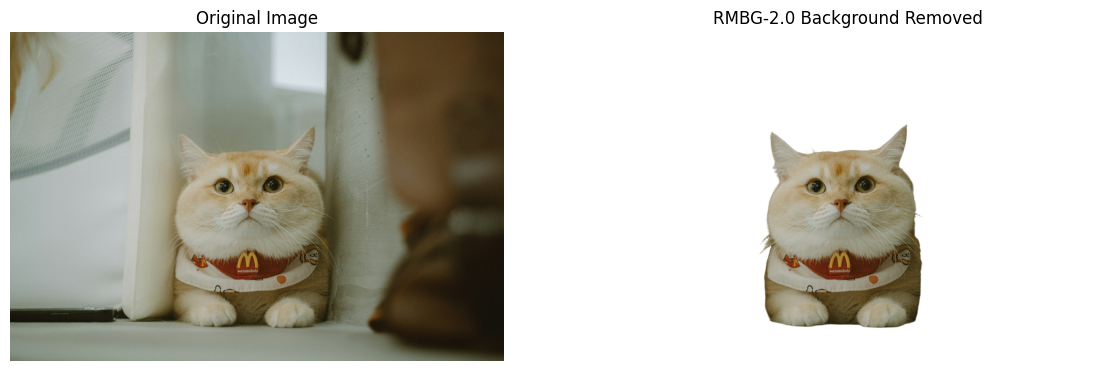

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(Image.open(input_image_path))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Image.open(output_path))
plt.title("RMBG-2.0 Background Removed")
plt.axis("off")

plt.show()